In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [2]:
# Check data types and missing values
print(df.dtypes)
print("\n")
print(df.isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0


In [3]:
# Fix TotalCharges — convert to numeric (blanks become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN appeared
print(df['TotalCharges'].isnull().sum())

# See those rows
print(df[df['TotalCharges'].isnull()])

11
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  .

In [4]:
# Fill missing TotalCharges with 0 (new customers, not yet billed)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Convert Churn to binary 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verify
print(df['TotalCharges'].isnull().sum())  # should be 0
print(df['Churn'].value_counts())          # should show 0 and 1

0
Churn
0    5174
1    1869
Name: count, dtype: int64


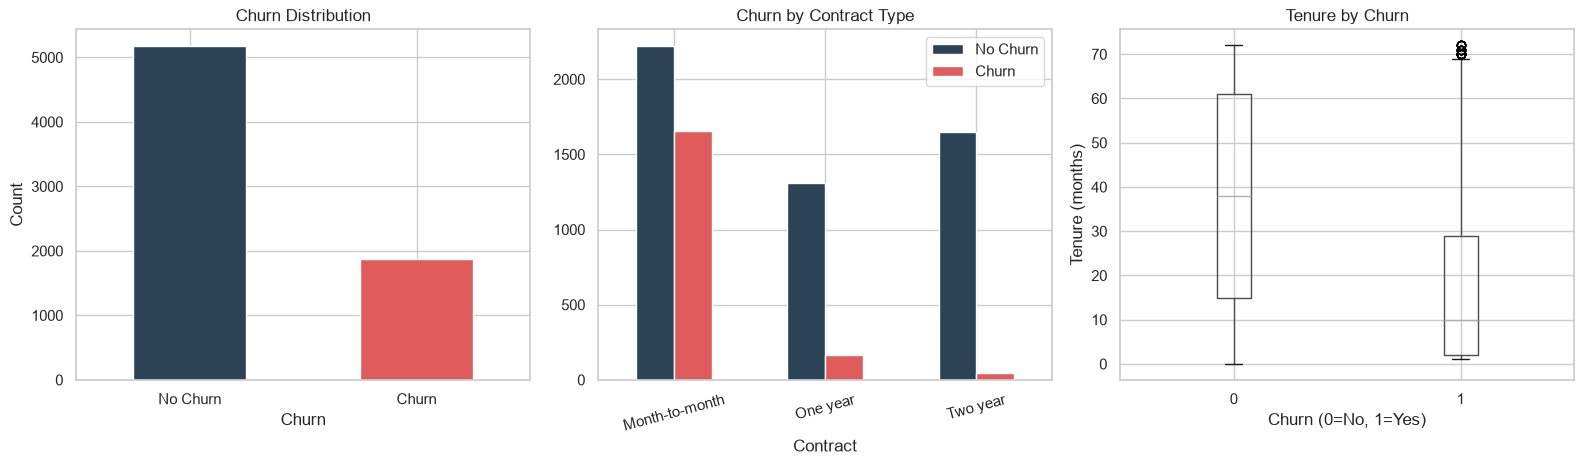

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Churn distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2B4257', '#E05C5C'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)
axes[0].set_ylabel('Count')

# 2. Churn by Contract Type
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', ax=axes[1], color=['#2B4257', '#E05C5C'])
axes[1].set_title('Churn by Contract Type')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(['No Churn', 'Churn'])

# 3. Tenure vs Churn
df.boxplot(column='tenure', by='Churn', ax=axes[2])
axes[2].set_title('Tenure by Churn')
axes[2].set_xlabel('Churn (0=No, 1=Yes)')
axes[2].set_ylabel('Tenure (months)')
plt.suptitle('')

plt.tight_layout()
plt.show()

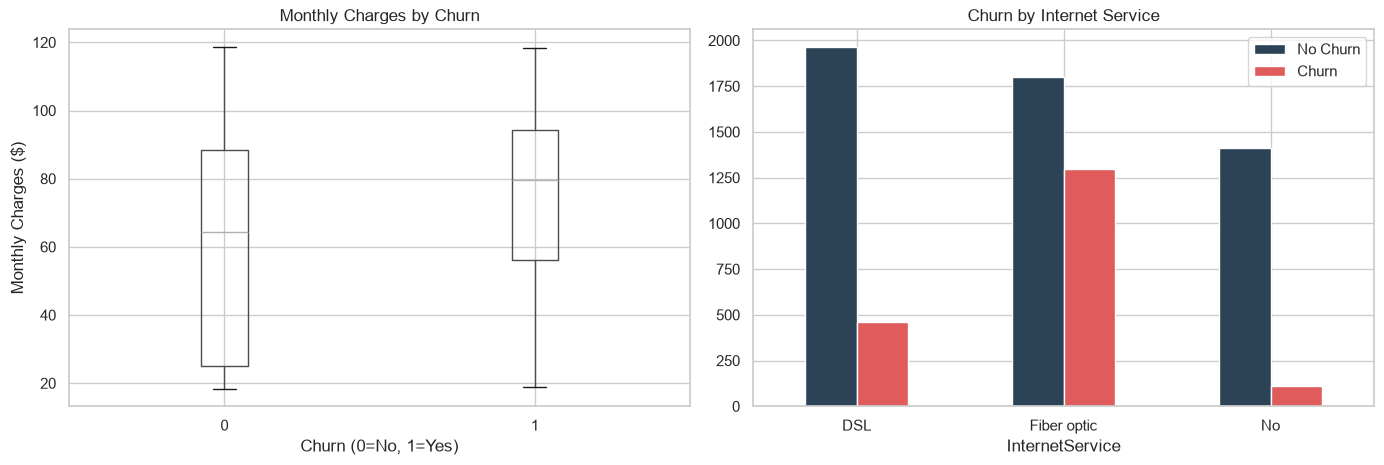

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0])
axes[0].set_title('Monthly Charges by Churn')
axes[0].set_xlabel('Churn (0=No, 1=Yes)')
axes[0].set_ylabel('Monthly Charges ($)')
plt.suptitle('')

# 2. Churn by Internet Service
pd.crosstab(df['InternetService'], df['Churn']).plot(
    kind='bar', ax=axes[1], color=['#2B4257', '#E05C5C']
)
axes[1].set_title('Churn by Internet Service')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [8]:
# EDA Summary
# Key churn drivers identified:
# 1. Contract type — month-to-month customers churn at highest rate
# 2. Tenure — new customers (low tenure) are most at risk
# 3. Internet service — fiber optic has disproportionately high churn
# 4. Monthly charges — churners pay higher monthly bills
# Ready to move to feature engineering and modeling
print("EDA complete. Key features identified: Contract, tenure, InternetService, MonthlyCharges")

EDA complete. Key features identified: Contract, tenure, InternetService, MonthlyCharges
